In [1]:
import os 
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = "...."

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPEN_API_KEY"] = "......."



In [3]:
from langchain.tools import tool
@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"


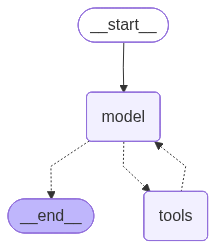

In [4]:
from langchain.agents import create_agent
agent = create_agent(
    model = "gpt-5",
    tools = [get_weather],
    system_prompt = "you are a helpful assistant"
)

agent

In [ ]:
response = agent.invoke({"messages":[{"role":"user","content":"What is the weather like in Banglore?"}]})

response
#ye Execute nhi krega qki openAI me Balance ni hai 

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
# response['message'][-1].content

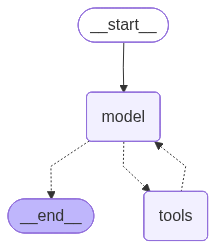

In [7]:
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = "....."
model = ChatGroq(model = "qwen/qwen3-32b")

agent = create_agent(
    model = model,
    tools = [get_weather],
    system_prompt = "you are a helpful assistant"
)

agent
 

In [8]:
response = agent.invoke({"messages":[{"role":"user","content":"What is the weather like in Banglore?"}]})

response

{'messages': [HumanMessage(content='What is the weather like in Banglore?', additional_kwargs={}, response_metadata={}, id='80962964-805b-4bcd-a5ac-697da9104950'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Banglore. Let me check the tools available. There\'s a function called get_weather that takes a location parameter. The user mentioned "Banglore," which I should verify is the correct spelling. Sometimes it\'s spelled Bangalore. But the function just requires the location as a string. I\'ll use "Banglore" as provided. I need to call get_weather with location set to Banglore. No other parameters are needed. Just make sure the JSON is correctly formatted. Let me structure the tool call accordingly.\n', 'tool_calls': [{'id': 't6srxds9z', 'function': {'arguments': '{"location":"Banglore"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 137, 'prompt_tokens': 161, '

In [10]:
response['messages'][-1].content

"The weather in Banglore is sunny right now! If you're there, it's a great day to enjoy outdoor activities. ☀️"